<a href="https://colab.research.google.com/github/KowshiqKatta/Fundamentals-of-Gen-AI-and-LLM/blob/main/Basic_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

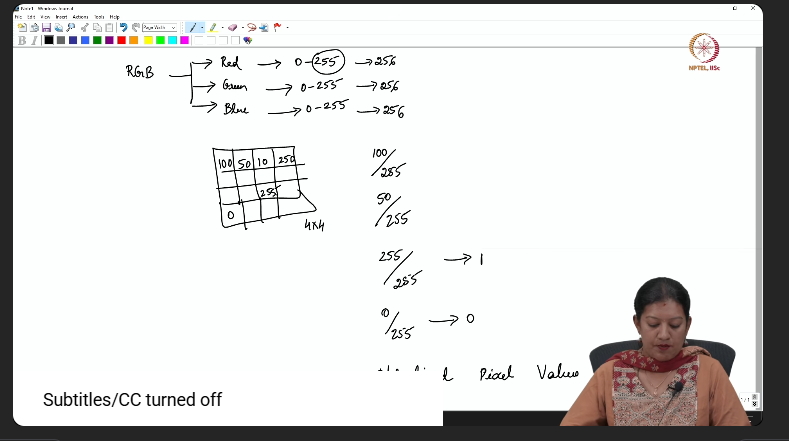

Load Dataset

In [2]:
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

x_train = x_train/255.0
x_test = x_test/255.0

class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1909s 11us/step
Training data shape: (50000, 32, 32, 3)
Testing data shape: (10000, 32, 32, 3)


Display Sample Images

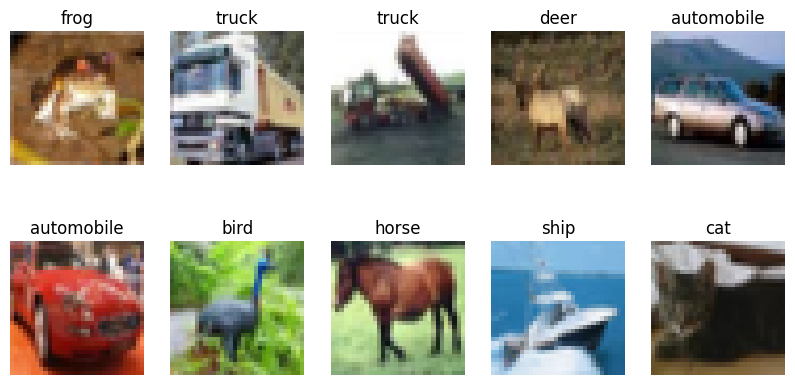

In [4]:
plt.figure(figsize = (10, 5))

for i in range(10):
  plt.subplot(2, 5, i + 1) # construction of image list array
  plt.imshow(x_train[i])
  plt.title(class_names[y_train[i][0]])
  plt.axis('off') # no need of x and y axis

plt.show()

Build CNN Model

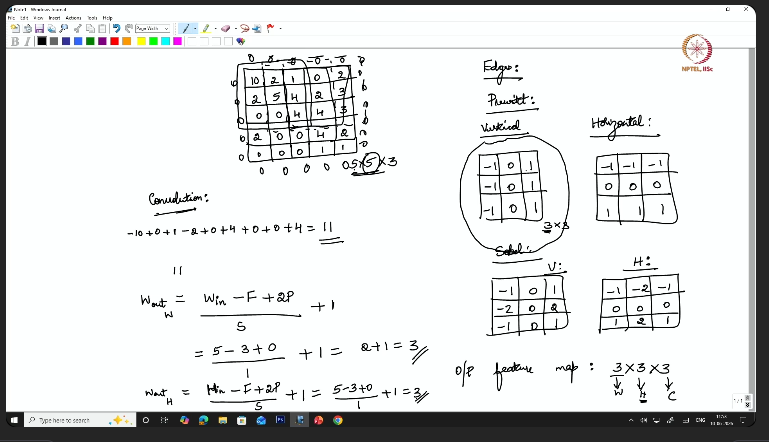

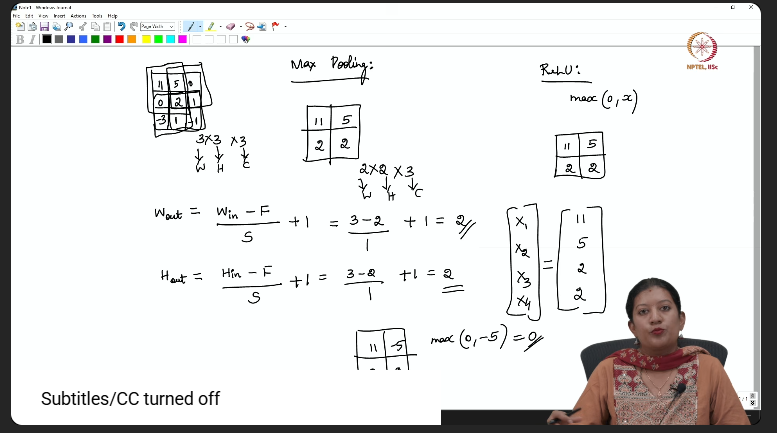

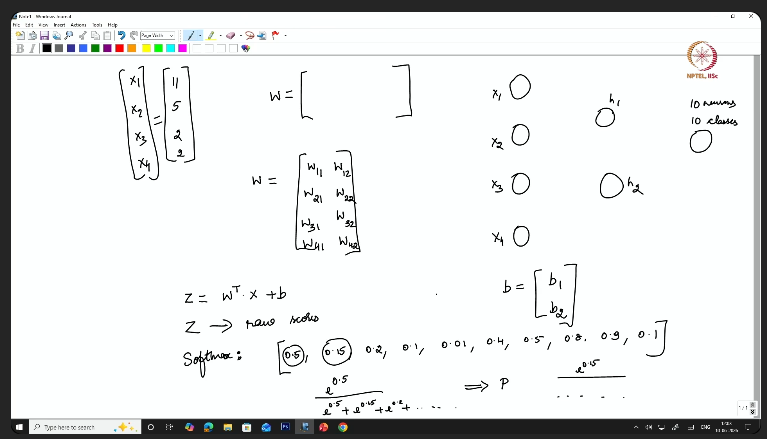

In [5]:
model = models.Sequential()

# first convulation block
model.add(layers.Conv2D(
    filters = 32,
    kernel_size = (3, 3),
    activation = 'relu',
    input_shape = (32, 32, 3)
))
model.add(layers.MaxPooling2D((2, 2)))

# second convulation block
model.add(layers.Conv2D(64, (3, 3), activation = 'relu'))
model.add(layers.MaxPooling2D((2, 2)))

# third convulation block
model.add(layers.Conv2D(128, (3, 3), activation = 'relu'))

# flatten layer
model.add(layers.Flatten())

# fully connected layers
model.add(layers.Dense(128, activation = 'relu'))
model.add(layers.Dropout(0.5)) # to drop some of the hidden neurons in order to generalise or regularize the model to avoid overfitting

# output layer
model.add(layers.Dense(10, activation = 'softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


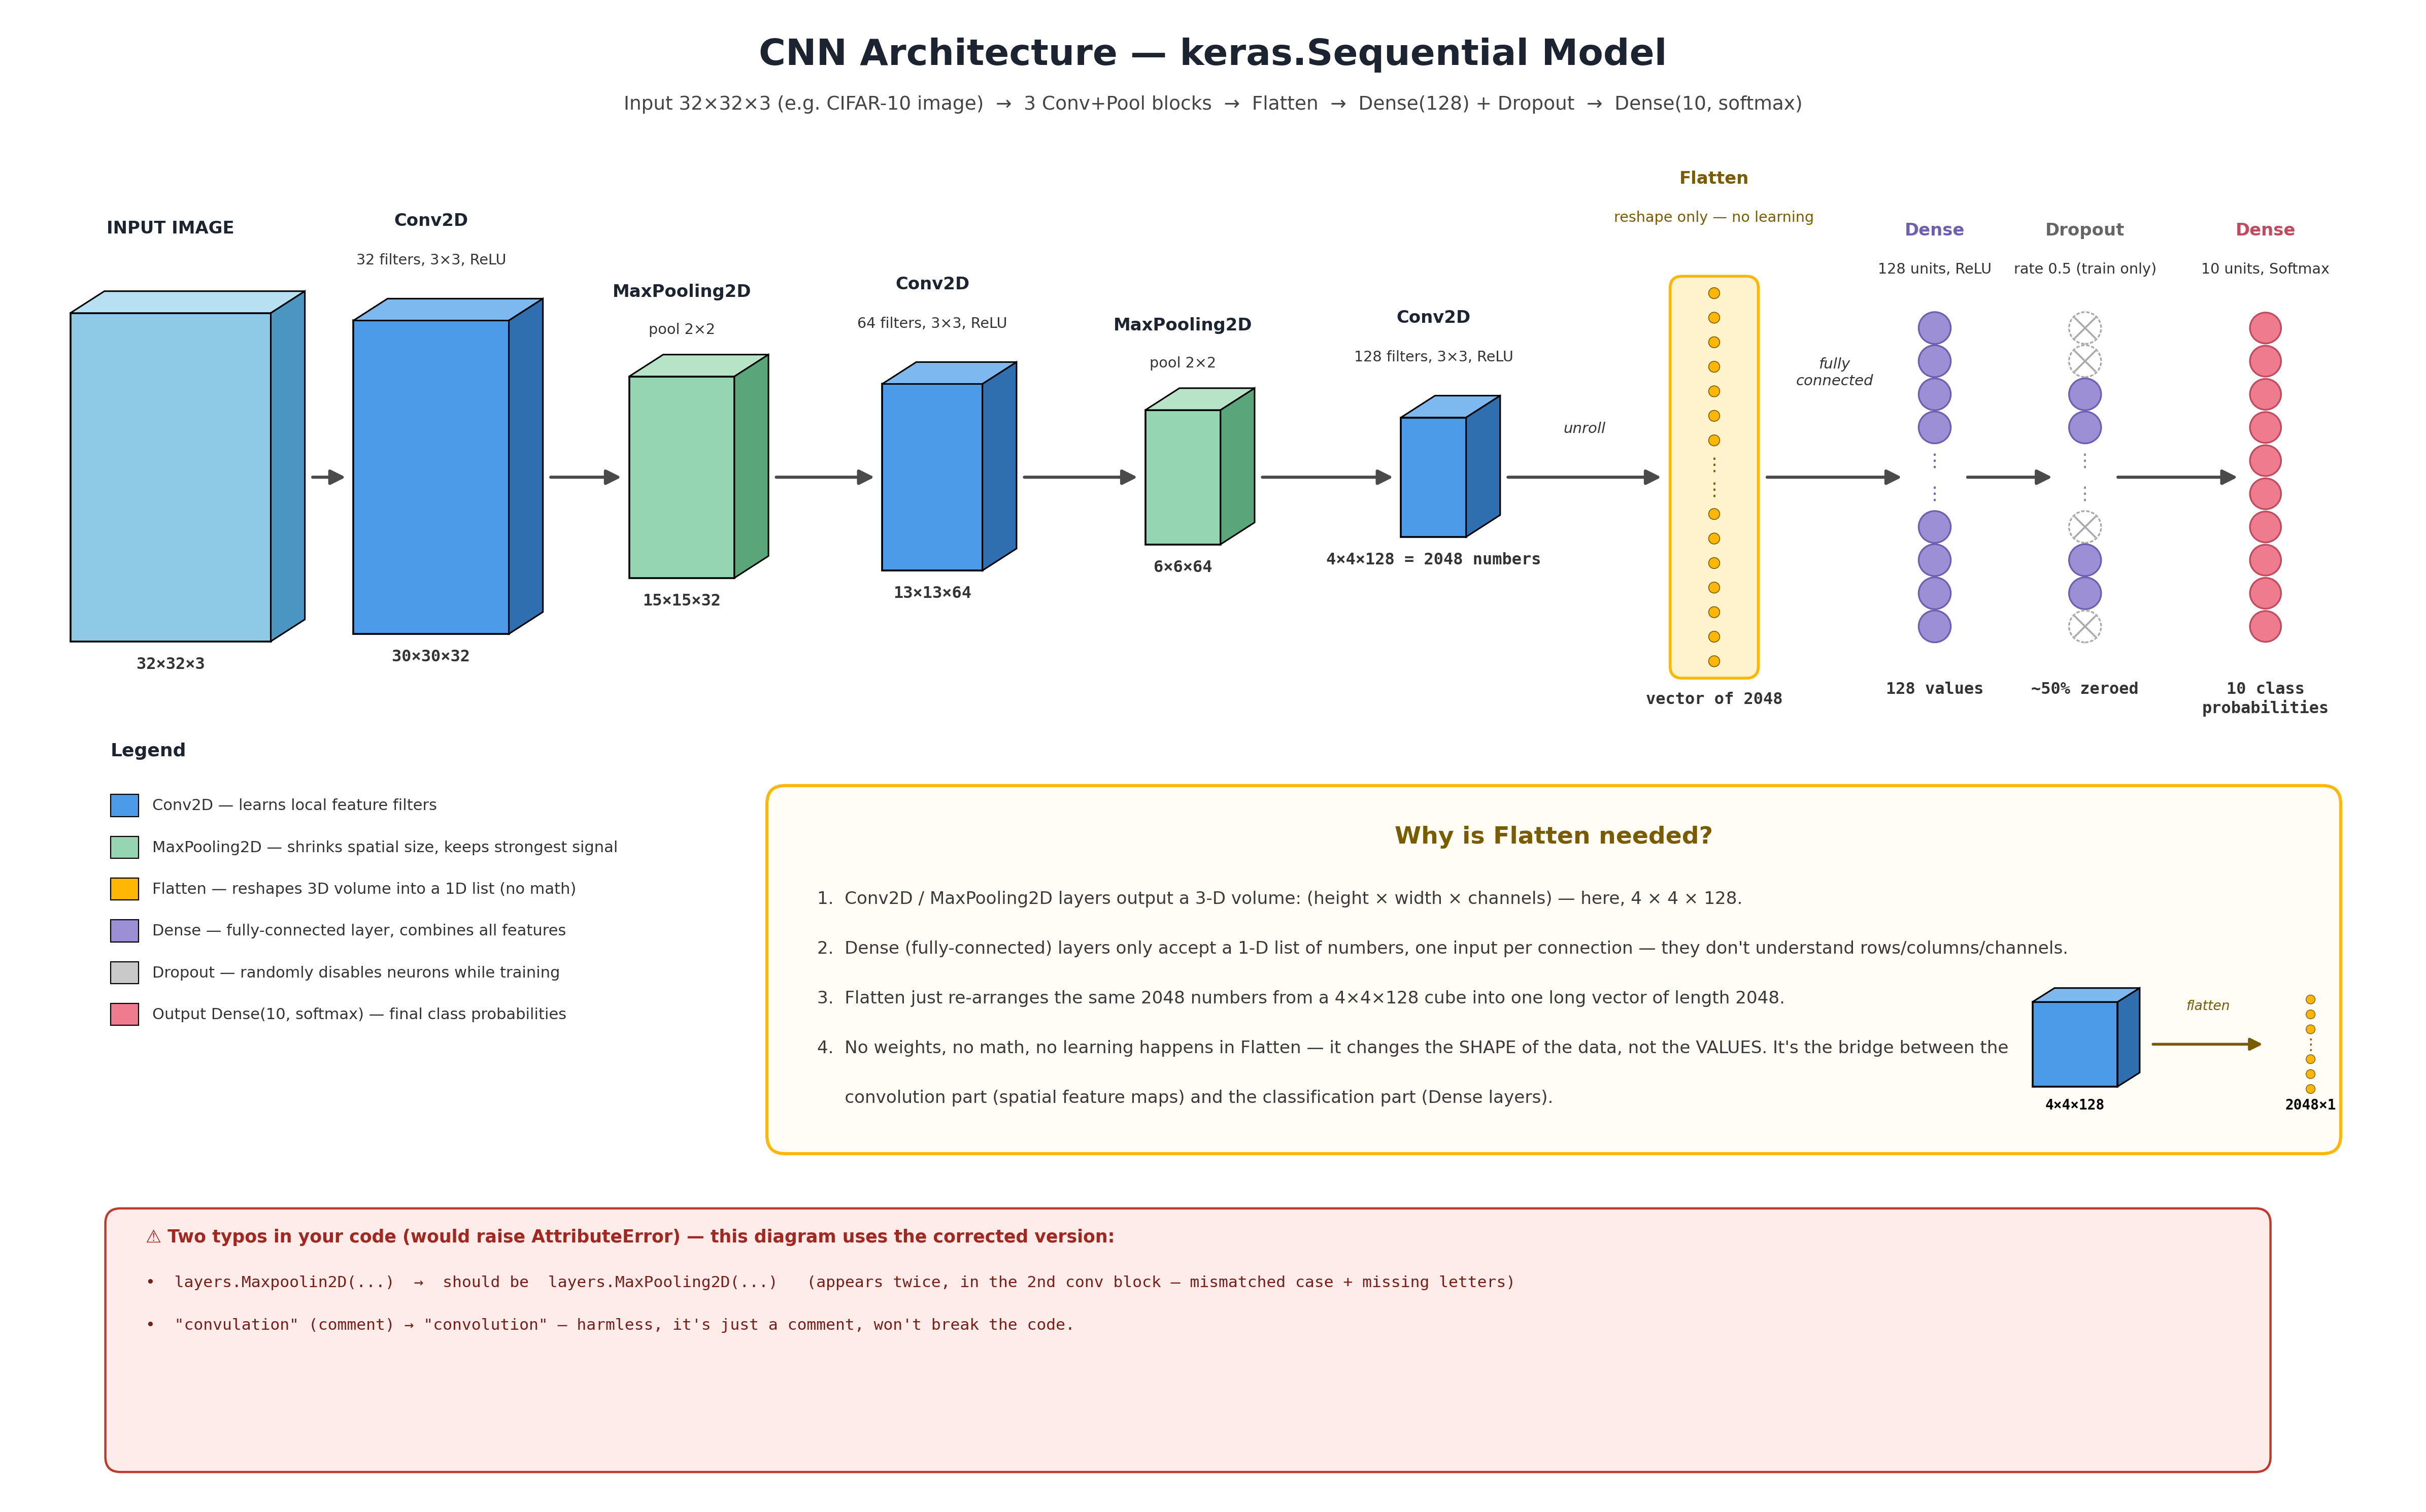

Compile Model

In [6]:
model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy', # recommended as the output is integers
    metrics = ['accuracy']
)

Train Model

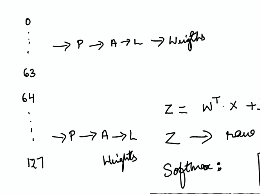

In [7]:
history = model.fit(
    x_train,
    y_train,
    epochs = 10,
    batch_size = 64,
    validation_split = 0.2,
    verbose = 1 #display every result of epoch in one line
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 91ms/step - accuracy: 0.3629 - loss: 1.7197 - val_accuracy: 0.4984 - val_loss: 1.4107
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 102s 124ms/step - accuracy: 0.5177 - loss: 1.3547 - val_accuracy: 0.5796 - val_loss: 1.1808
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 78s 118ms/step - accuracy: 0.5808 - loss: 1.1985 - val_accuracy: 0.6223 - val_loss: 1.0777
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 71s 114ms/step - accuracy: 0.6150 - loss: 1.0904 - val_accuracy: 0.6340 - val_loss: 1.0236
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 92ms/step - accuracy: 0.6510 - loss: 1.0006 - val_accuracy: 0.6668 - val_loss: 0.9359
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 88ms/step - accuracy: 0.6776 - loss: 0.9266 - val_accuracy: 0.6720 - val_loss: 0.9419
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 87ms/step - accuracy: 0.6987 - loss: 0.8683 - val_accuracy: 0.6972 - val_loss: 0.8747
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 85ms/step - accuracy: 0.7144 - loss: 0.818

Plot accuracy and Loss

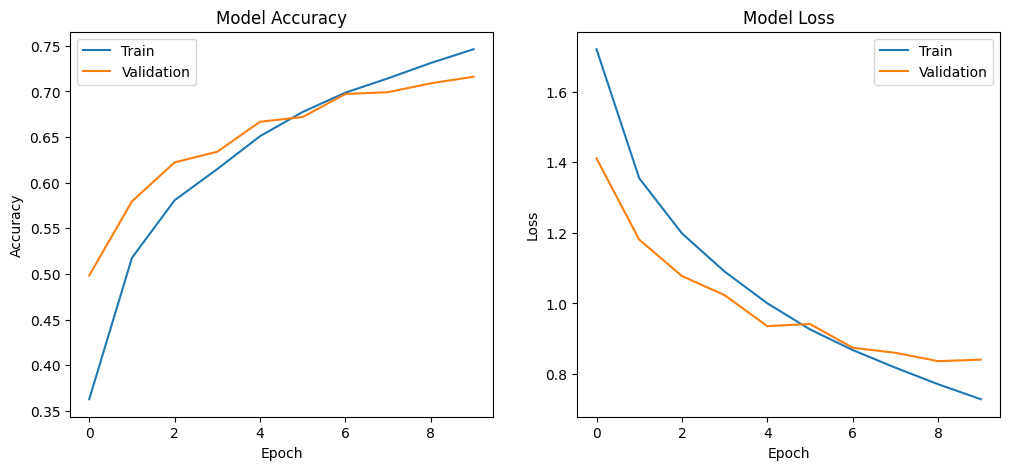

In [8]:
plt.figure(figsize = (12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label = 'Train')
plt.plot(history.history['val_accuracy'], label = 'Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label = 'Train')
plt.plot(history.history['val_loss'], label = 'Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

Evaluate on Test Data

In [9]:
test_loss, test_acc = model.evaluate(x_test, y_test)

print("\nTest Accuracy:", test_acc)
print("\nTest Loss:", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.7128 - loss: 0.8393

Test Accuracy: 0.7128000259399414

Test Loss: 0.8392627239227295


Predictions

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


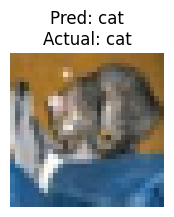

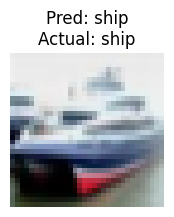

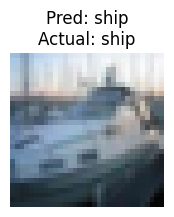

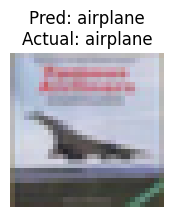

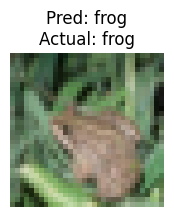

In [10]:
predictions = model.predict(x_test)

for i in range(5):
  predicted_label = np.argmax(predictions[i])
  actual_label = y_test[i][0]

  plt.figure(figsize = (2, 2))
  plt.imshow(x_test[i])
  plt.title(
      f"Pred: {class_names[predicted_label]}\n"
      f"Actual: {class_names[actual_label]}"
  )
  plt.axis('off')
  plt.show()

Confusion Matrix

<Figure size 1000x800 with 0 Axes>

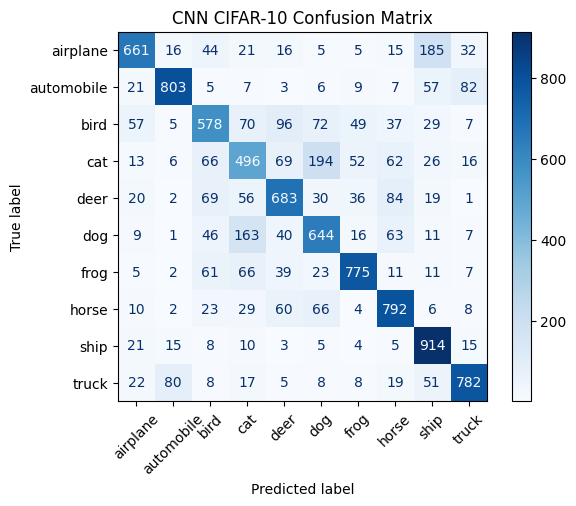

In [11]:
# predicted labels
y_pred = np.argmax(predictions, axis = 1)

# True labels
y_true = y_test.flatten()

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Display confusion matrix
plt.figure(figsize = (10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels = class_names
)
disp.plot(cmap = 'Blues', xticks_rotation = 45)

plt.title("CNN CIFAR-10 Confusion Matrix")
plt.show()